In [1]:
import pandas as pd
import numpy as np

In [2]:
import statsmodels.api as sm 
from statsmodels.formula.api import ols
import scipy.stats as stats
import statsmodels.stats.anova as anova
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
from scipy.stats import levene

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [4]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'

In [5]:
df = pd.read_excel(fpath + '\\6.0_database_variables.xlsx')

In [6]:
# Rename columns
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'week(1=free days)': 'weekday_type'})

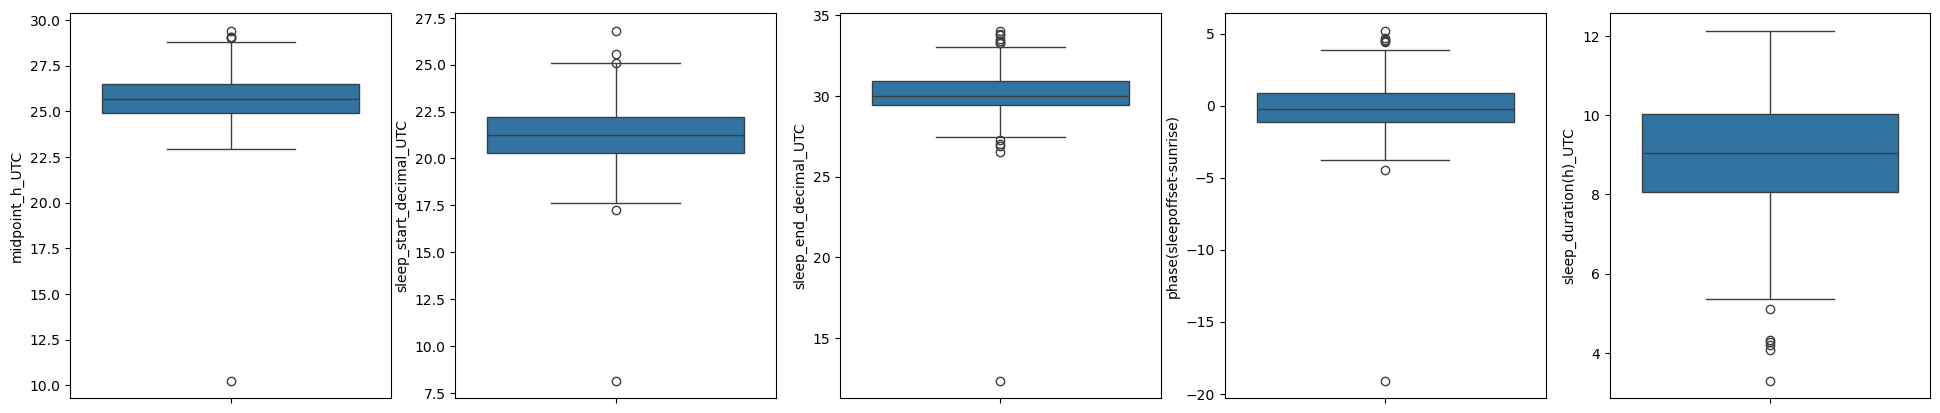

In [7]:
# box plot to verify the outliers in midpoint, sleep onset, sleep offset, phase, and sleep duration
fig, ax = plt.subplots(1, 5, figsize=(24, 5))
sns.boxplot(data=df['midpoint_h_UTC'], ax=ax[0])
sns.boxplot(data=df['sleep_start_decimal_UTC'], ax=ax[1])
sns.boxplot(data=df['sleep_end_decimal_UTC'], ax=ax[2])
sns.boxplot(data=df['phase(sleepoffset-sunrise)'], ax=ax[3])
sns.boxplot(data=df['sleep_duration(h)_UTC'], ax=ax[4])

plt.show()

In [8]:
# remove outliers
# criteria: zscore of 3 means that the data point is 3 standard deviations away from the mean
df = df[(np.abs(stats.zscore(df['sleep_duration(h)_UTC'])) < 3)] 
df = df[(np.abs(stats.zscore(df['midpoint_h_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]

In [9]:
# delete columns that are not needed
df = df.drop('sunrise_time(USA)', axis=1)
df = df.drop('sunrise (USA), hours', axis=1)
df = df.drop('sunset (USA), hours', axis=1)
df = df.drop('sunset_time(USA)', axis=1)
df = df.drop('photoperiod (h, USA)', axis=1)

In [10]:
# define the start date
start_date = pd.to_datetime('2022-02-01')

In [11]:
# function to count the week of the year from the start date 2022-02-01
def calculate_week_of_year(start_datetime):
    return (start_datetime - start_date).days // 7 + 5

# apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [12]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [13]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday_type'] = df['weekday_type'].map({0: 'work days', 1: 'free days'})

In [14]:
# calculate the sleep duration for work days and free days
df['sleep_duration(h)_UTC'] = df['sleep_duration(h)_UTC'].astype(float)
df['sleep_duration_work_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'work days')
df['sleep_duration_free_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'free days')

In [15]:
# filtered the midpoints by type of day of the week
# new dataframe with only the midpoints of the work days/free days
df_workdays = df[df['weekday_type'] == 'work days']
df_freedays = df[df['weekday_type'] == 'free days']

In [16]:
# create a new df for weekly jetlag analysis
data_jetlag_UTC = df 

In [17]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag_UTC = data_jetlag_UTC.groupby(['location', 'week_of_year', 'weekday_type'])['midpoint_h_UTC'].mean().unstack()

In [18]:
# calculate the jet lag for week and weekday
weekly_means_jetlag_UTC['jet lag_UTC'] = weekly_means_jetlag_UTC['free days'] - weekly_means_jetlag_UTC['work days']

In [19]:
# add a column with the location to the weekly_means_jetlag_UTC
weekly_means_jetlag_UTC['location'] = weekly_means_jetlag_UTC.index.get_level_values(0)

In [20]:
# save the weekly_means_jetlag_UTC to an excel file
weekly_means_jetlag_UTC.to_excel(fpath + '\\weekly_means_jetlag_UTC.xlsx')

In [21]:
# rename columns
df = df.rename(columns={'sleep_duration(h)_UTC': 'sleep_duration_UTC'})
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})

In [22]:
# Adding a 'season' column to the dataset based on the 'date' column
# Defining seasons based on months: 
# Winter (Dec-Feb), Spring (Mar-May), Summer (Jun-Aug), Autumn (Sep-Nov)
def assign_season(date):
    month = pd.to_datetime(date).month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

In [23]:
# Applying the function to create a season column
df_workdays['season'] = df_workdays['date'].apply(assign_season)
df_freedays['season'] = df_freedays['date'].apply(assign_season)
df['season'] = df['date'].apply(assign_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_26656\2974399819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays['season'] = df_workdays['date'].apply(assign_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_26656\2974399819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays['season'] = df_freedays['date'].apply(assign_season)


In [24]:
# create a new variable 'photoperiod' based on the location
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df['photoperiod'] = np.where(df['location'] == 'UK', df['photoperiod (h, UK)'], df['photoperiod (h, ITA)'])

In [25]:
# add a column with the photoperiod for the UK and ITA
df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] 
df_workdays.loc[df_workdays['location'] == 'ITA', 'photoperiod'] = df_workdays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_26656\1608732957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)']


In [26]:
# add the photoperiod column to the df_freedays
df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']
df_freedays.loc[df_freedays['location'] == 'ITA', 'photoperiod'] = df_freedays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_26656\2381324628.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']


In [27]:
# descpriptive statistics
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

In [28]:
# descpriptive statistics for ITA
descriptive_ita = df[df['location'] == 'ITA'].describe()
descriptive_ita = descriptive_ita.transpose()

In [29]:
# descpriptive statistics for UK
descriptive_uk = df[df['location'] == 'UK'].describe()
descriptive_uk = descriptive_uk.transpose()

In [30]:
# avg number of days after the flight
mean_days_after_flight = df['day_after_flight'].mean()
std_days_after_flight = df['day_after_flight'].std()

print('Mean of days after flight:', mean_days_after_flight)
print('Std of days after flight:', std_days_after_flight)

Mean of days after flight: 8.690812720848056
Std of days after flight: 6.212019782711081


In [31]:
# days after the flight by location
mean_days_after_flight_location = df.groupby('location')['day_after_flight'].mean()
std_days_after_flight_location = df.groupby('location')['day_after_flight'].std()

mean_std_days_after_flight_location = pd.concat([mean_days_after_flight_location, std_days_after_flight_location], axis=1)
mean_std_days_after_flight_location.columns = ['mean', 'std']

In [32]:
mean_std_days_after_flight_location

,mean,std
location,,
ITA,9.863501,7.129692
UK,6.965066,3.961282


In [33]:
# % of time spent in each location
count_location = df['location'].value_counts(normalize=True) * 100

In [34]:
count_location

location
ITA    59.540636
UK     40.459364
Name: proportion, dtype: float64

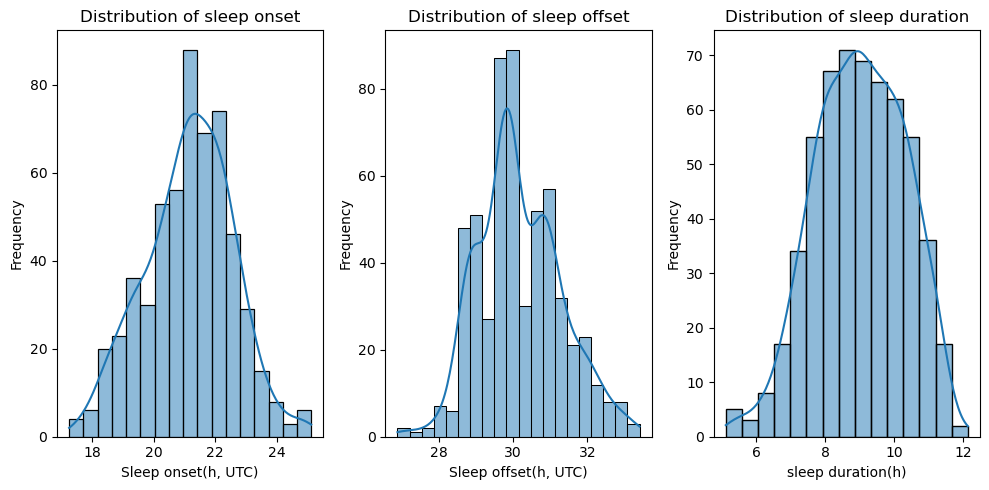

In [35]:
# distribution of the midpoint, sleep onset, sleep offset, and sleep duration
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_start_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep onset")
plt.xlabel("Sleep onset(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(df['sleep_end_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep offset")
plt.xlabel("Sleep offset(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(df['sleep_duration_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep duration")
plt.xlabel("sleep duration(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

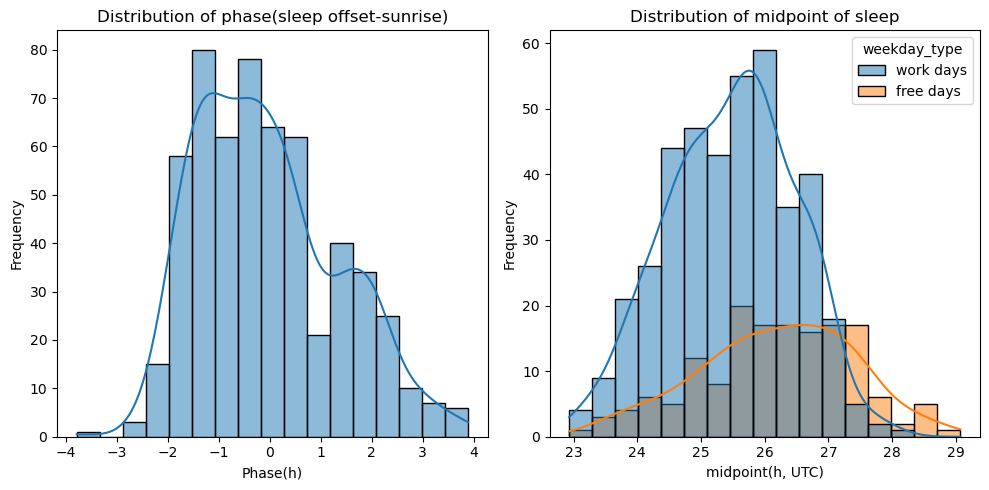

In [36]:
# distribution of phase and midpoint of sleep
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['phase'].dropna(), kde=True)
plt.title("Distribution of phase(sleep offset-sunrise)")
plt.xlabel("Phase(h)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='midpoint_h_UTC', hue='weekday_type', kde=True)
plt.title("Distribution of midpoint of sleep")
plt.xlabel("midpoint(h, UTC)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [37]:
# test normality of the data using Shapiro-Wilk test 
# Null hipotesis(H0): data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration_UTC'])
shapiro_test_midpoint = stats.shapiro(df['midpoint_h_UTC'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal_UTC'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal_UTC'])
shapiro_test_phase = stats.shapiro(df['phase'])

In [38]:
shapiro_results_x = pd.DataFrame({
    'Variable': ['sleep_duration(h)', 'midpoint_h_UTC', 'sleep_start_decimal_UTC', 'sleep_end_decimal_UTC', 'phase(sleepoffset-sunrise)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_midpoint, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase]
})

In [39]:
shapiro_results_x

,Variable,Shapiro-Wilk test
0,sleep_duration(h),"(0.9902246610911858, 0.0008226033160291848)"
1,midpoint_h_UTC,"(0.9966098081502522, 0.27825571498290286)"
2,sleep_start_decimal_UTC,"(0.9938769987889519, 0.021848420182686012)"
3,sleep_end_decimal_UTC,"(0.9836545244937268, 5.6566874049762885e-06)"
4,phase(sleepoffset-sunrise),"(0.9661064505005437, 3.7966420613702094e-10)"


In [40]:
# test normality of the data using Shapiro-Wilk test for work days and free days (midpoint of sleep)
shapiro_test_midpoint_free = stats.shapiro(df[df['weekday_type'] == 'free days']['midpoint_h_UTC'])
shapiro_test_midpoint_work = stats.shapiro(df[df['weekday_type'] == 'work days']['midpoint_h_UTC'])

In [41]:
shapiro_results_free_work = pd.DataFrame({
    'Weekday type': ['free days', 'work days'],
    'Shapiro-Wilk test': [shapiro_test_midpoint_free, shapiro_test_midpoint_work]
})

In [42]:
shapiro_results_free_work

,Weekday type,Shapiro-Wilk test
0,free days,"(0.9894810197523596, 0.29179366919766936)"
1,work days,"(0.9929247333891301, 0.050973709866609325)"


In [43]:
# descriptive statistics by location
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [44]:
# compare the variables between ITA and UK
ttest_midpoint_all_loc = stats.ttest_ind(df[df['location'] == 'ITA']['midpoint_h_UTC'], df[df['location'] == 'UK']['midpoint_h_UTC'])
ttest_midpoint_workdays_loc = stats.ttest_ind(df_workdays[df_workdays['location'] == 'ITA']['midpoint_h_UTC'], df_workdays[df_workdays['location'] == 'UK']['midpoint_h_UTC'])
ttest_midpoint_freedays_loc = stats.ttest_ind(df_freedays[df_freedays['location'] == 'ITA']['midpoint_h_UTC'], df_freedays[df_freedays['location'] == 'UK']['midpoint_h_UTC'])
utest_duration_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_duration_UTC'], df[df['location'] == 'UK']['sleep_duration_UTC'])
utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase'], df[df['location'] == 'UK']['phase'])
utest_start_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_start_decimal_UTC'], df[df['location'] == 'UK']['sleep_start_decimal_UTC'])
utest_end_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_end_decimal_UTC'], df[df['location'] == 'UK']['sleep_end_decimal_UTC'])

In [45]:
# print the results
print('T test results by location')
print('Midpoint_all:', ttest_midpoint_all_loc)
print('Midpoint_work:', ttest_midpoint_workdays_loc)
print('Midpoint_free:', ttest_midpoint_freedays_loc)
print('U test results by location')
print('Sleep_onset:', utest_start_loc)
print('Sleep_offset:', utest_end_loc)
print('Sleep_duration:', utest_duration_loc)
print('Phase:', utest_phase_loc)

T test results by location
Midpoint_all: TtestResult(statistic=-7.3130654557098556, pvalue=9.004103854577647e-13, df=564.0)
Midpoint_work: TtestResult(statistic=-7.002582947406899, pvalue=1.044280679209457e-11, df=407.0)
Midpoint_free: TtestResult(statistic=-3.8479181254840364, pvalue=0.00017370196992224848, df=155.0)
U test results by location
Sleep_onset: MannwhitneyuResult(statistic=29056.0, pvalue=6.015842573800659e-07)
Sleep_offset: MannwhitneyuResult(statistic=24049.5, pvalue=2.6869544574564792e-14)
Sleep_duration: MannwhitneyuResult(statistic=37477.0, pvalue=0.561399767835371)
Phase: MannwhitneyuResult(statistic=23915.0, pvalue=1.5550312393417045e-14)


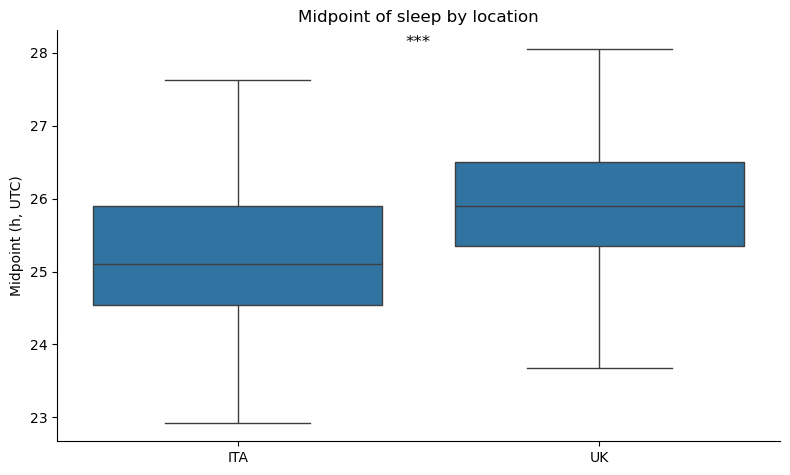

In [46]:
# plot the midpoint of sleep by location
plt.figure(figsize=(8, 5))
sns.boxplot(x='location', y='midpoint_h_UTC', data=df_workdays)
plt.title('Midpoint of sleep by location')
plt.suptitle('')  
plt.xlabel('')
plt.ylabel('Midpoint (h, UTC)')

plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

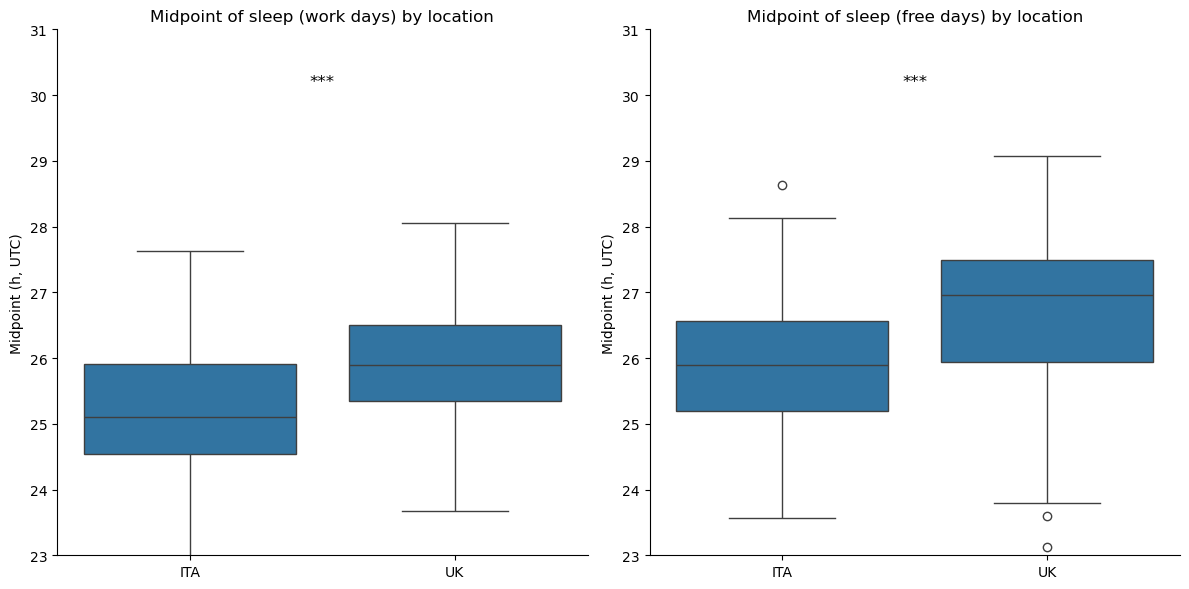

In [47]:
# plot the midpoint of sleep by location for free days and work days
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x='location', y='midpoint_h_UTC', data=df_workdays, ax=ax[0])
ax[0].set_title('Midpoint of sleep (work days) by location')
ax[0].set_ylabel('Midpoint (h, UTC)')
ax[0].set_xlabel('')
ax[0].yaxis.set_major_locator(MultipleLocator(1))
ax[0].set_ylim(23, 31)
ax[0].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line of ** for the p-value < 0.001

sns.boxplot(x='location', y='midpoint_h_UTC', data=df_freedays, ax=ax[1])
ax[1].set_title('Midpoint of sleep (free days) by location')
ax[1].set_ylabel('Midpoint (h, UTC)')
ax[1].set_xlabel('')
ax[1].yaxis.set_major_locator(MultipleLocator(1))
ax[1].set_ylim(ax[0].get_ylim())
ax[1].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line of  for the p-value < 0.001
    
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.tight_layout()
plt.show()

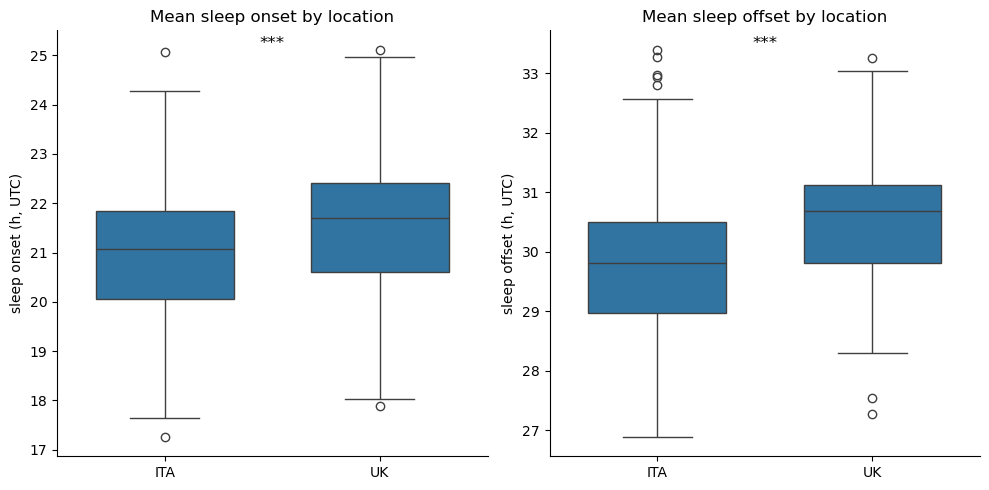

In [48]:
# plot the sleep onset and sleep offset by location
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='sleep_start_decimal_UTC', data=df, gap=0.2)
plt.title('Mean sleep onset by location')
plt.xlabel('')
plt.ylabel('sleep onset (h, UTC)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot

plt.subplot(1, 2, 2)
sns.boxplot(x='location', y='sleep_end_decimal_UTC', data=df, gap=0.2)
plt.title('Mean sleep offset by location')
plt.xlabel('')
plt.ylabel('sleep offset (h, UTC)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot

sns.despine()
plt.tight_layout()
plt.show()

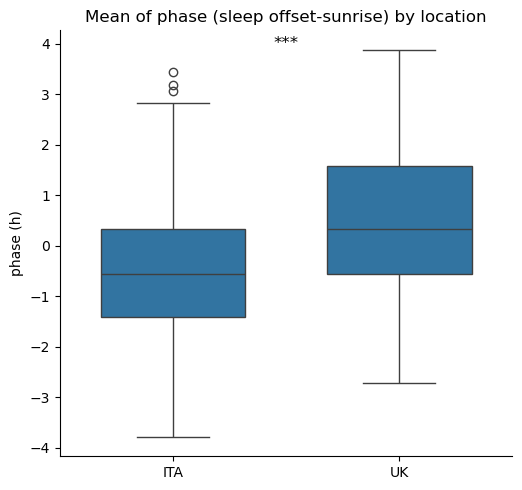

In [49]:
# plot the phase (sleep offset-sunrise) by location 
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='phase', data=df, gap=0.2)
plt.title('Mean of phase (sleep offset-sunrise) by location')
plt.xlabel('')
plt.ylabel('phase (h)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

_Weekly Jetlag_

In [50]:
# drop the rows with missing values
jetlag_clean = weekly_means_jetlag_UTC['jet lag_UTC'].dropna()

In [51]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_clean)

In [52]:
print('Shapiro test result for jet lag:')
print(shapiro_test_jetlag)

Shapiro test result for jet lag:
ShapiroResult(statistic=0.9658908356235015, pvalue=0.015610375282271051)


In [53]:
# test the difference in jet lag between the two locations
utest_jetlag = stats.mannwhitneyu(weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'ITA']['jet lag_UTC'].dropna(), weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'UK']['jet lag_UTC'].dropna())

In [54]:
print('U test result for jet lag by location:')
print(utest_jetlag)

U test result for jet lag by location:
MannwhitneyuResult(statistic=1049.5, pvalue=0.9750606867138256)


_Season and sleep-wake pattern_

In [55]:
# remove NaN values from the columns and create a new dataframe
df1 = df.dropna(subset=['sleep_duration_UTC']) 
df1 = df.dropna(subset=['phase'])

In [56]:
ols_midpoint_season = ols('midpoint_h_UTC ~ C(season)', data=df1).fit() # generate and fit the regression model
anova_midpoint_result_season = sm.stats.anova_lm(ols_midpoint_season, typ=3) # fit the ANOVA model and get the results

In [57]:
print('ANOVA Result:')
print(anova_midpoint_result_season)

ANOVA Result:
                  sum_sq     df              F        PR(>F)
Intercept  102371.567512    1.0  100113.864660  0.000000e+00
C(season)     105.640046    3.0      34.436753  1.919444e-20
Residual      574.673859  562.0            NaN           NaN


In [58]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season1 = pairwise_tukeyhsd(df1['midpoint_h_UTC'], df1['season'])
print(tukey_results_season1)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.0253  0.997 -0.2949 0.3455  False
Autumn Summer  -0.2435 0.1953 -0.5597 0.0728  False
Autumn Winter   0.8439    0.0   0.558 1.1299   True
Spring Summer  -0.2687 0.1789 -0.6102 0.0727  False
Spring Winter   0.8186    0.0   0.505 1.1323   True
Summer Winter   1.0874    0.0  0.7778  1.397   True
---------------------------------------------------


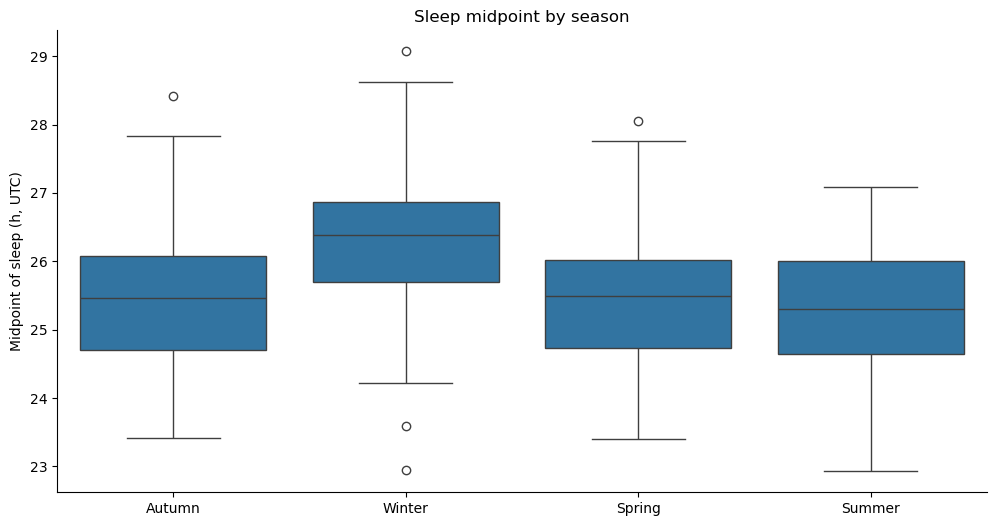

In [59]:
# sleep midpoint by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midpoint_h_UTC', data=df1)
plt.title('Sleep midpoint by season')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Midpoint of sleep (h, UTC)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') 
plt.gca().spines['left'].set_color('black')
plt.show()

In [60]:
# Kruskal-Wallis test : compare the sleep duration, phase, sleep onset, and sleep offset between the seasons
kw_sleep_duration_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_duration_UTC'], df[df['season'] == 'Spring']['sleep_duration_UTC'], df[df['season'] == 'Summer']['sleep_duration_UTC'], df[df['season'] == 'Autumn']['sleep_duration_UTC'])
kw_phase_season = stats.kruskal(df[df['season'] == 'Winter']['phase'], df[df['season'] == 'Spring']['phase'], df[df['season'] == 'Summer']['phase'], df[df['season'] == 'Autumn']['phase'])
kw_start_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_start_decimal_UTC'], df[df['season'] == 'Spring']['sleep_start_decimal_UTC'], df[df['season'] == 'Summer']['sleep_start_decimal_UTC'], df[df['season'] == 'Autumn']['sleep_start_decimal_UTC'])
kw_end_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_end_decimal_UTC'], df[df['season'] == 'Spring']['sleep_end_decimal_UTC'], df[df['season'] == 'Summer']['sleep_end_decimal_UTC'], df[df['season'] == 'Autumn']['sleep_end_decimal_UTC'])

In [61]:
print('Results for Kruskal-Wallis test for the sleep duration by season')
print(kw_sleep_duration_season)
print('Results for Kruskal-Wallis test for the phase by season')
print(kw_phase_season)
print('Results for Kruskal-Wallis test for the sleep onset by season')
print(kw_start_season)
print('Results for Kruskal-Wallis test for the sleep offset by season')
print(kw_end_season)

Results for Kruskal-Wallis test for the sleep duration by season
KruskalResult(statistic=1.5978437208009528, pvalue=0.6598788403583598)
Results for Kruskal-Wallis test for the phase by season
KruskalResult(statistic=205.67649777702235, pvalue=2.5034834728697753e-44)
Results for Kruskal-Wallis test for the sleep onset by season
KruskalResult(statistic=53.86323177380167, pvalue=1.2000065049226613e-11)
Results for Kruskal-Wallis test for the sleep offset by season
KruskalResult(statistic=88.20097144611152, pvalue=5.332390398690246e-19)


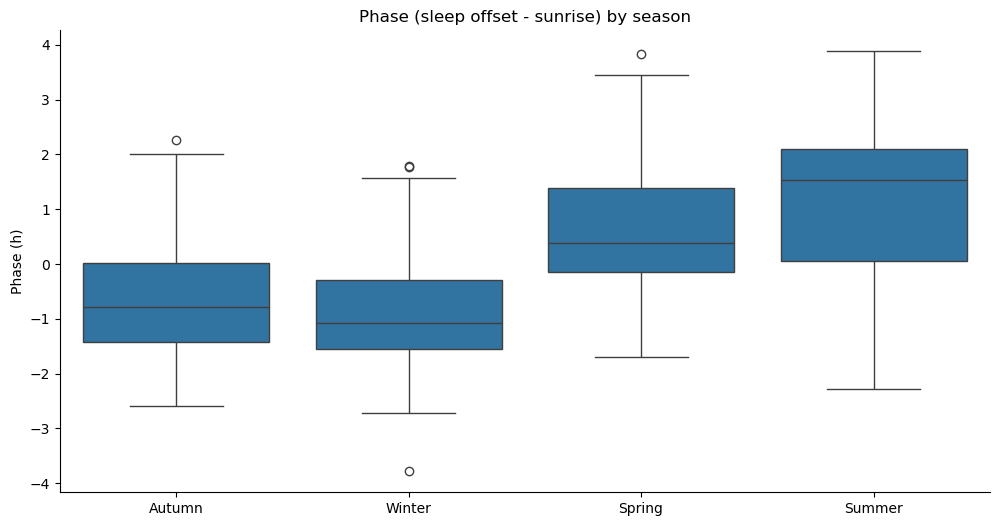

In [62]:
# phase (sleep offset - sunrise) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='phase', data=df)
plt.title('Phase (sleep offset - sunrise) by season')
plt.suptitle('')  # add space after the title
plt.ylabel('Phase (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

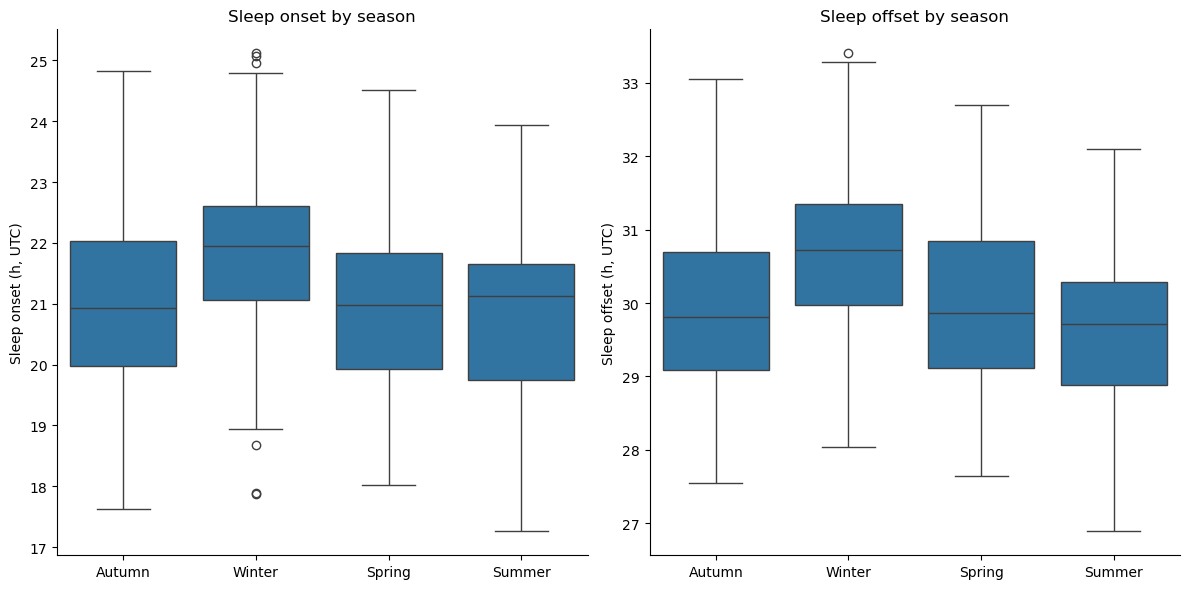

In [63]:
# sleep onset and offset by season
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='season', y='sleep_start_decimal_UTC', data=df)
plt.title('Sleep onset by season')
plt.ylabel('Sleep onset (h, UTC)')
plt.xlabel('')

plt.subplot(1, 2, 2)
sns.boxplot(x='season', y='sleep_end_decimal_UTC', data=df)
plt.title('Sleep offset by season')
plt.ylabel('Sleep offset (h, UTC)')
plt.xlabel('')

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

_DST and sleep-wake pattern_

In [64]:
# rename the column
df = df.rename(columns={'DST(0=ST)': 'DST_0'})

In [65]:
# remove the rows with missing values in the columns
df2 = df.dropna(subset=['sleep_duration_UTC'])
df2 = df.dropna(subset=['phase'])

In [66]:
# t-test to compare the midpoint of sleep between DST and non-DST
ttest_sleep_midpoint_dst = stats.ttest_ind(df2[df2['DST_0'] == 0]['midpoint_h_UTC'], df2[df2['DST_0'] == 1]['midpoint_h_UTC'])

In [67]:
print('T test result for the sleep midpoint by DST:')
print(ttest_sleep_midpoint_dst)

T test result for the sleep midpoint by DST:
TtestResult(statistic=12.127071907036333, pvalue=3.072883514461234e-30, df=564.0)


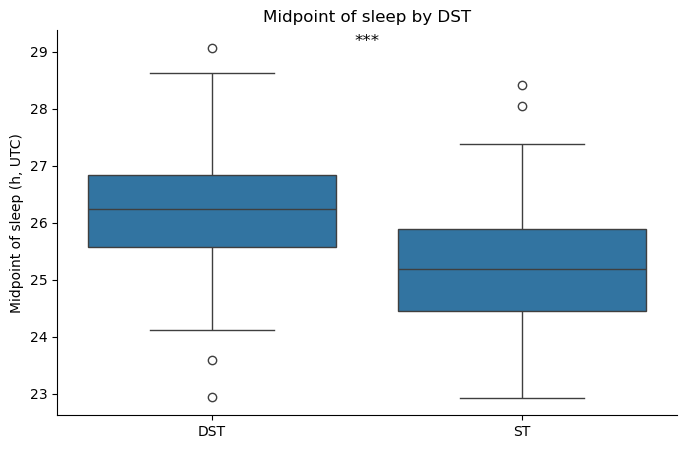

In [68]:
# sleep midpoint by DST
plt.figure(figsize=(8, 5))
sns.boxplot(x='DST_0', y='midpoint_h_UTC', data=df2)
plt.title('Midpoint of sleep by DST')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of sleep (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [69]:
# Mann Whitney U test : compare the sleep duration, phase, sleep onset, and sleep offset between DST and non-DST
utest_sleep_duration_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['sleep_duration_UTC'], df2[df2['DST_0'] == 1]['sleep_duration_UTC'])
utest_phase_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['phase'], df2[df2['DST_0'] == 1]['phase'])
utest_start_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['sleep_start_decimal_UTC'], df2[df2['DST_0'] == 1]['sleep_start_decimal_UTC'])
utest_end_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['sleep_end_decimal_UTC'], df2[df2['DST_0'] == 1]['sleep_end_decimal_UTC'])

In [70]:
print('Results for Mann-Whitney U test for the sleep duration by dst')
print(utest_sleep_duration_dst)
print('Results for Mann-Whitney U test for the phase by dst')
print(utest_phase_dst)
print('Results for Mann-Whitney U test for the sleep onset by dst')
print(utest_start_dst)
print('Results for Mann-Whitney U test for the sleep offset by dst')
print(utest_end_dst)

Results for Mann-Whitney U test for the sleep duration by dst
MannwhitneyuResult(statistic=41376.5, pvalue=0.47021257694661267)
Results for Mann-Whitney U test for the phase by dst
MannwhitneyuResult(statistic=20608.5, pvalue=2.2141842948728922e-23)
Results for Mann-Whitney U test for the sleep onset by dst
MannwhitneyuResult(statistic=55781.5, pvalue=4.15816290978017e-16)
Results for Mann-Whitney U test for the sleep offset by dst
MannwhitneyuResult(statistic=62558.5, pvalue=3.2286855812609277e-31)


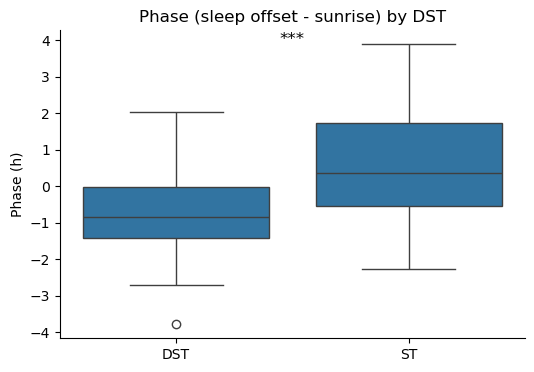

In [71]:
# phase (sleep offset - sunrise) by DST
plt.figure(figsize=(6, 4))
sns.boxplot(x='DST_0', y='phase', data=df2)
plt.title('Phase (sleep offset - sunrise) by DST')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (h)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
sns.despine()
plt.grid(False)
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

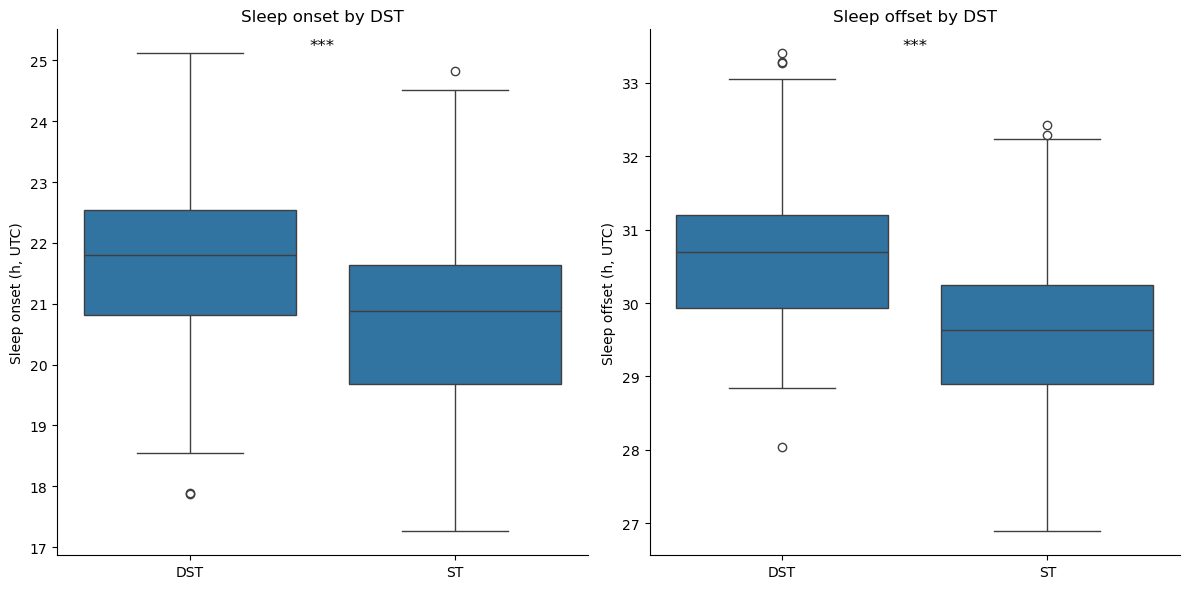

In [72]:
# sleep onset and offset by DST
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='DST_0', y='sleep_start_decimal_UTC', data=df2)
plt.title('Sleep onset by DST')
plt.ylabel('Sleep onset (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(x='DST_0', y='sleep_end_decimal_UTC', data=df2)
plt.title('Sleep offset by DST')
plt.ylabel('Sleep offset (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

_Photoperiod and sleep-wake pattern_

In [73]:
# correlation between sleep-wake variables and photoperiod
correlation_test1 = stats.pearsonr(df['midpoint_h_UTC'], df['photoperiod'])
correlation_test2 = stats.pearsonr(df_workdays['midpoint_h_UTC'], df_workdays['photoperiod'])
correlation_test3 = stats.pearsonr(df_freedays['midpoint_h_UTC'], df_freedays['photoperiod'])
correlation_test4 = stats.spearmanr(df['sleep_duration_UTC'], df['photoperiod'])
correlation_test5 = stats.spearmanr(df['sleep_end_decimal_UTC'], df['photoperiod'])

In [74]:
# extract the coefficients and p-values from the correlation test results
pearson_coeff = [correlation_test1.statistic, correlation_test2.statistic, correlation_test3.statistic, correlation_test4.statistic, correlation_test5.correlation]
p_values = [correlation_test1.pvalue, correlation_test2.pvalue, correlation_test3.pvalue, correlation_test4.pvalue, correlation_test5.pvalue]

In [75]:
# create a DataFrame with the results
correlation_results = pd.DataFrame({
    'Variables': ['midpoint UTC vs photoperiod', 'midpoint (work) UTC vs photoperiod', 'midpoint (free) UTC vs photoperiod', 'sleep duration UTC vs photoperiod', 'sleep offset UTC vs photoperiod'],
    'Coefficient': pearson_coeff,
    'P-value': p_values
})

correlation_results

,Variables,Coefficient,P-value
0,midpoint UTC vs photoperiod,-0.368148,1.313417e-19
1,midpoint (work) UTC vs photoperiod,-0.381068,1.389815e-15
2,midpoint (free) UTC vs photoperiod,-0.390352,4.326967e-07
3,sleep duration UTC vs photoperiod,-0.016755,6.908110e-01
4,sleep offset UTC vs photoperiod,-0.390613,4.510522e-22


_Weekly IV, IS and RA_

In [76]:
# load the datasets required for the analysis
weekly_values = pd.read_csv(fpath + '\\2.0_weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag_UTC

In [77]:
# split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [78]:
# convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [79]:
# merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

In [80]:
merged_data.head()

,week_of_year,Date_Range,IS,IV,RA,Start_Date,End_Date,free days,work days,jet lag_UTC,location
0,15,2023-04-12 to 2023-04-18,NaN,0.024172,NaN,2023-04-12,2023-04-18,26.437500,25.821875,0.615625,ITA
1,32,2023-08-09 to 2023-08-15,NaN,0.048807,NaN,2023-08-09,2023-08-15,24.600000,25.093333,-0.493333,ITA
2,31,2024-07-31 to 2024-08-06,NaN,0.027033,0.949047,2024-07-31,2024-08-06,26.460417,24.690625,1.769792,ITA
3,33,2023-08-16 to 2023-08-22,NaN,0.053677,0.948446,2023-08-16,2023-08-22,26.397917,25.026667,1.371250,UK
4,9,2023-03-01 to 2023-03-07,NaN,0.040270,0.953698,2023-03-01,2023-03-07,26.406250,25.628333,0.777917,ITA


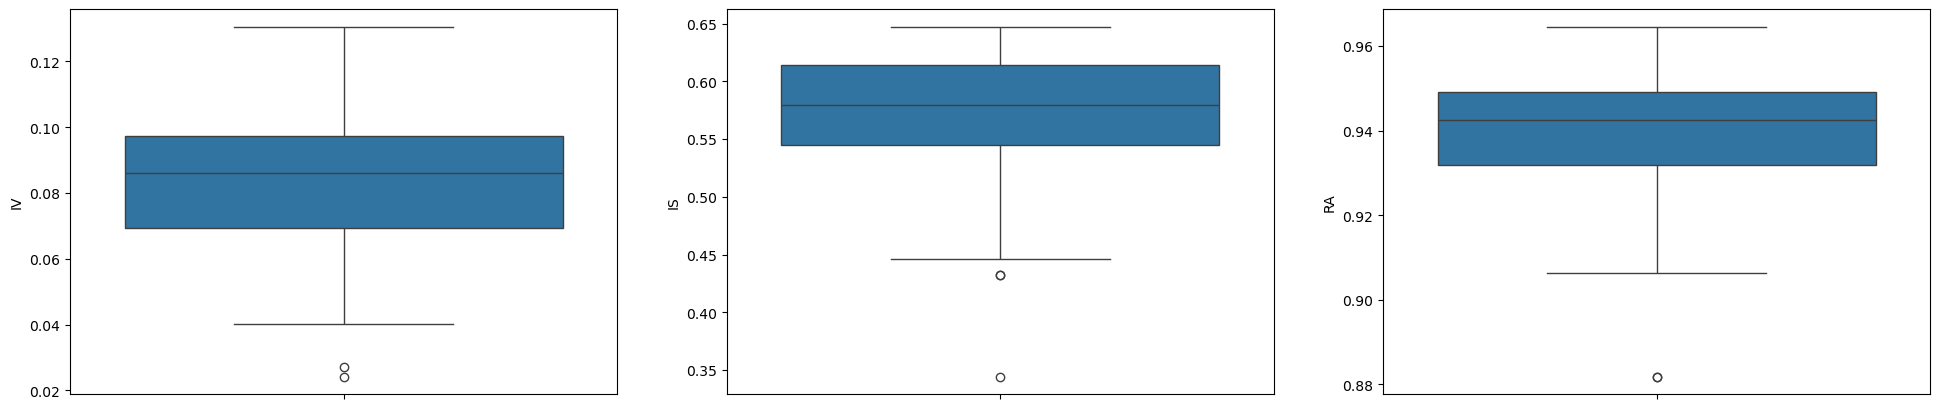

In [81]:
# box plot to verify the outliers in IV, IS, and RA
fig, ax = plt.subplots(1, 3, figsize=(24, 5))
sns.boxplot(data=merged_data['IV'], ax=ax[0])
sns.boxplot(data=merged_data['IS'], ax=ax[1])
sns.boxplot(data=merged_data['RA'], ax=ax[2])
plt.show()

In [82]:
# summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()
summary_stats

IV                                                              \
         count      mean       std       min       25%       50%       75%   
location                                                                     
ITA       53.0  0.080466  0.022129  0.024172  0.067942  0.082638  0.093785   
UK        36.0  0.088307  0.017596  0.053677  0.075609  0.087177  0.098561   

                      IS            ...                        RA            \
               max count      mean  ...       75%       max count      mean   
location                            ...                                       
ITA       0.130562  48.0  0.574327  ...  0.614767  0.647358  50.0  0.940170   
UK        0.130562  34.0  0.567904  ...  0.613489  0.645810  34.0  0.937674   

                                                                     
              std       min       25%       50%       75%       max  
location                                                             
ITA       0.01533  0.881815  0.931972  0.942574  0.950680  0.964584  
UK        0.01699  0.881815  0.930985  0.942574  0.947245  0.962952  

[2 rows x 24 columns]

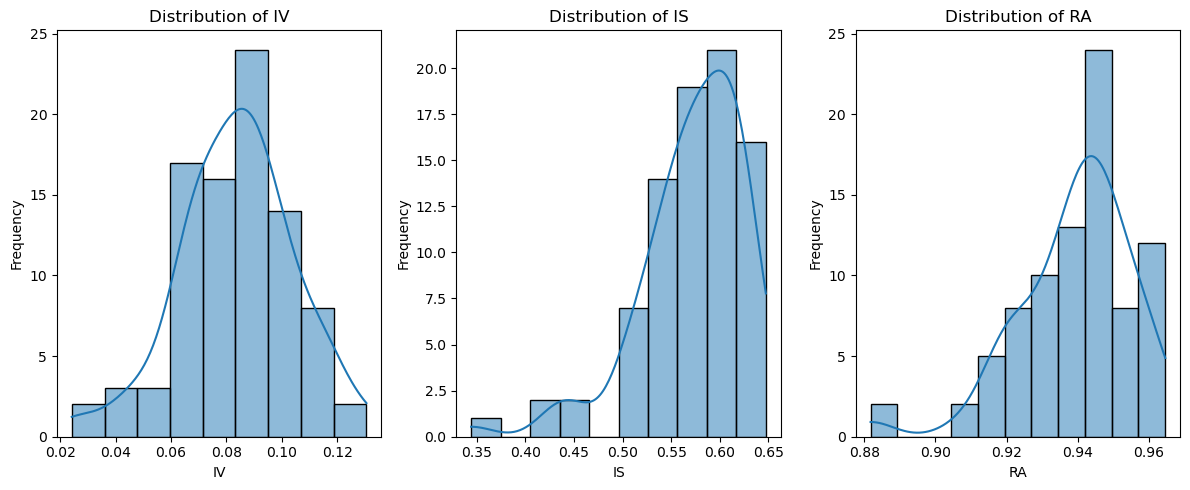

In [83]:
# distribution of IV, IS, and RA
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title('Distribution of IV')
plt.xlabel('IV')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')
 
plt.subplot(1, 3, 3)
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title('Distribution of RA')
plt.xlabel('RA')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [84]:
# compare the variables between ITA and UK
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_ttest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [85]:
print('Test results for IV by location:', iv_ttest)
print('Test results for IS by location:', is_ttest)
print('Test results for RA by location:', ra_ttest)

Test results for IV by location: TtestResult(statistic=-1.7772445658632352, pvalue=0.07902284498496115, df=87.0)
Test results for IS by location: MannwhitneyuResult(statistic=869.5, pvalue=0.6178431739272754)
Test results for RA by location: TtestResult(statistic=0.7007288217997164, pvalue=0.4854559109859711, df=82.0)


_Midsleep vs days after flight_

In [86]:
# filter the data by the days after the flight (7)
midsleep_bydays_after_flight = df[df['day_after_flight'] <= 7]

In [87]:
# add a column with the id
midsleep_bydays_after_flight['subject'] = 1

C:\Users\gg00642\AppData\Local\Temp\ipykernel_26656\1218469063.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  midsleep_bydays_after_flight['subject'] = 1


In [88]:
# group by location
midsleep_bydays_after_flight_uk = midsleep_bydays_after_flight[midsleep_bydays_after_flight['location'] == 'UK']
midsleep_bydays_after_flight_ita = midsleep_bydays_after_flight[midsleep_bydays_after_flight['location'] == 'ITA']

In [89]:
# mixed model analysis for the midpoint of sleep by days after the flight for UK 
model_1 = smf.mixedlm('midpoint_h_UTC ~ day_after_flight', midsleep_bydays_after_flight_uk, groups=midsleep_bydays_after_flight_uk['subject']).fit()

print(model_1.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: midpoint_h_UTC
No. Observations: 128     Method:             REML          
No. Groups:       1       Scale:              1.0743        
Min. group size:  128     Log-Likelihood:     -188.8336     
Max. group size:  128     Converged:          Yes           
Mean group size:  128.0                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         26.186    1.057 24.784 0.000 24.115 28.257
day_after_flight  -0.034    0.046 -0.740 0.459 -0.125  0.056
Group Var          1.074                                    



c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


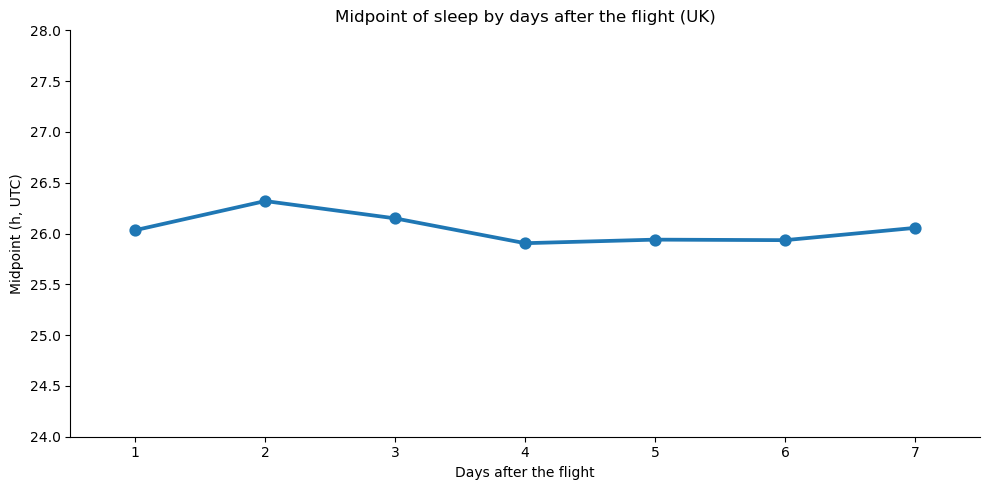

In [90]:
# plot the RM Anova for the midpoint of sleep by days after the flight (UK)
plt.figure(figsize=(10, 5))
sns.pointplot(x='day_after_flight', y='midpoint_h_UTC', data=midsleep_bydays_after_flight_uk, errorbar=None)
plt.title('Midpoint of sleep by days after the flight (UK)')
plt.xlabel('Days after the flight')
plt.ylabel('Midpoint (h, UTC)')
plt.ylim(24, 28)
plt.grid(False)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.tight_layout()
plt.show()

In [91]:
# mixed model analysis for the midpoint of sleep by days after the flight for ITA
model_2 = smf.mixedlm('midpoint_h_UTC ~ day_after_flight', midsleep_bydays_after_flight_ita, groups=midsleep_bydays_after_flight_ita['subject']).fit()  

print(model_2.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: midpoint_h_UTC
No. Observations: 144     Method:             REML          
No. Groups:       1       Scale:              1.1575        
Min. group size:  144     Log-Likelihood:     -217.5375     
Max. group size:  144     Converged:          Yes           
Mean group size:  144.0                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         25.829    1.094 23.606 0.000 23.684 27.973
day_after_flight  -0.117    0.045 -2.600 0.009 -0.205 -0.029
Group Var          1.158                                    



c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [92]:
# test normality of the residuals
shapiro_test_residuals = stats.shapiro(model_2.resid)

print('Shapiro test result for the residuals:', shapiro_test_residuals)

Shapiro test result for the residuals: ShapiroResult(statistic=0.994414855383496, pvalue=0.8540697384613651)


In [93]:
# group the data by days after the flight for the Levene's test
grouped_data = midsleep_bydays_after_flight_ita.groupby("day_after_flight")["midpoint_h_UTC"].apply(list).values

In [94]:
# Levene test to check the homogeneity of variances
stat, p_value = levene(*grouped_data)
print(f"Levene test statistic: {stat}")
print(f"P-value: {p_value}")

Levene test statistic: 0.179328828036626
P-value: 0.9820840333746115


In [95]:
# test indipendence of the residuals
# Durbin-Watson test: values around 2 indicate no autocorrelation
durbin_watson_test = sm.stats.stattools.durbin_watson(model_2.resid)

print('Durbin-Watson test result:', durbin_watson_test) 

Durbin-Watson test result: 1.3778821839420294


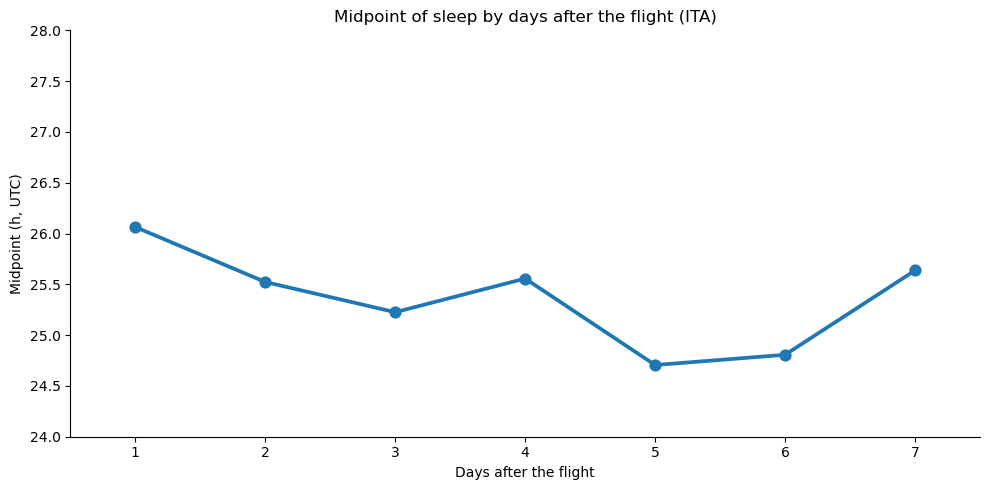

In [96]:
# plot the midpoint of sleep by days after the flight (ITA)
plt.figure(figsize=(10, 5))
sns.pointplot(x='day_after_flight', y='midpoint_h_UTC', data=midsleep_bydays_after_flight_ita, errorbar=None)
plt.title('Midpoint of sleep by days after the flight (ITA)')
plt.xlabel('Days after the flight')
plt.ylabel('Midpoint (h, UTC)')
plt.ylim(24, 28)
plt.grid(False)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.tight_layout()
plt.show()

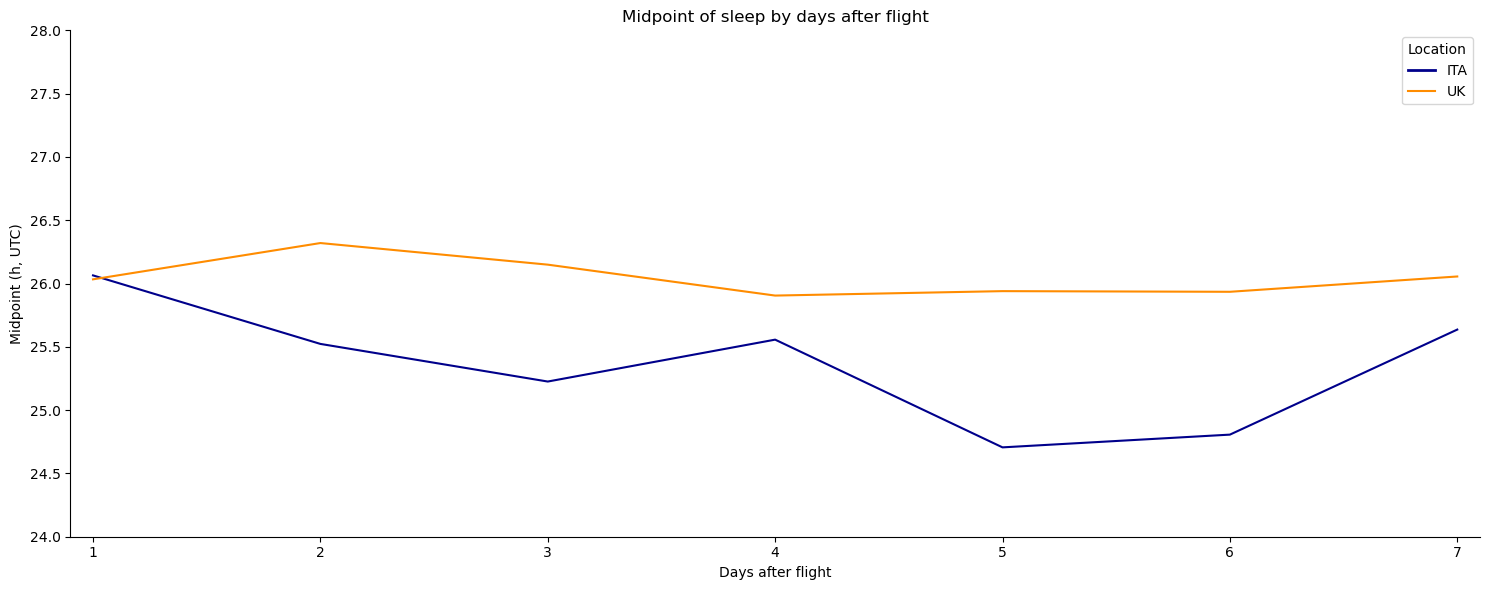

In [97]:
plt.figure(figsize=(15, 6))
sns.lineplot(x='day_after_flight', y='midpoint_h_UTC', hue='location', data=midsleep_bydays_after_flight, palette=['darkblue', 'darkorange'], errorbar=None)
plt.title('Midpoint of sleep by days after flight')
plt.xlabel('Days after flight')
plt.ylabel('Midpoint (h, UTC)')
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange')])
plt.grid(False)
plt.xticks()
plt.tight_layout()
plt.xlim(0.9,7.1)
plt.ylim(24, 28)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.gca().xaxis.set_major_locator(MultipleLocator(1)) 

plt.show()

In [98]:
# filter the data by the days after the flight (7days)
midsleep_bydays_after_flight_7 = df[df['day_after_flight'].astype(int) <= 7]

In [99]:
model_3a = smf.mixedlm('midpoint_h_UTC ~ day_after_flight + location + DST_0 + photoperiod', midsleep_bydays_after_flight_7, groups=midsleep_bydays_after_flight_7['day_after_flight'])  # Può essere sostituito con un identificativo unico se disponibile

result3a = model_3a.fit()

print(result3a.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: midpoint_h_UTC
No. Observations: 272     Method:             REML          
No. Groups:       7       Scale:              0.8316        
Min. group size:  37      Log-Likelihood:     -370.6701     
Max. group size:  40      Converged:          Yes           
Mean group size:  38.9                                      
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         26.395    0.412 64.036 0.000 25.587 27.203
location[T.UK]     0.642    0.111  5.786 0.000  0.425  0.860
day_after_flight  -0.078    0.048 -1.632 0.103 -0.171  0.016
DST_0             -0.961    0.199 -4.834 0.000 -1.351 -0.571
photoperiod       -0.015    0.036 -0.419 0.675 -0.086  0.056
Group Var          0.042    0.045                           



In [100]:
model_3b = smf.mixedlm('midpoint_h_UTC ~ day_after_flight + location + DST_0 + season', midsleep_bydays_after_flight_7, groups=midsleep_bydays_after_flight_7['day_after_flight'])  # Può essere sostituito con un identificativo unico se disponibile

result3b = model_3b.fit()

print(result3b.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: midpoint_h_UTC
No. Observations: 272     Method:             REML          
No. Groups:       7       Scale:              0.8302        
Min. group size:  37      Log-Likelihood:     -369.7782     
Max. group size:  40      Converged:          Yes           
Mean group size:  38.9                                      
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         26.058    0.261 99.972 0.000 25.547 26.569
location[T.UK]     0.638    0.111  5.752 0.000  0.421  0.856
season[T.Spring]   0.120    0.159  0.755 0.451 -0.192  0.431
season[T.Summer]   0.138    0.173  0.801 0.423 -0.201  0.478
season[T.Winter]   0.271    0.181  1.492 0.136 -0.085  0.626
day_after_flight  -0.077    0.048 -1.615 0.106 -0.171  0.016
DST_0             -0.925    0.169 -5

_Phase by location, time, DST and season_

In [101]:
# drop the rows with missing values in the columns
data_phase = df.dropna(subset=['phase', 'location', 'date', 'photoperiod', 'season', 'DST_0'])

In [102]:
# location coded as 0=ITA, 1=UK
data_phase['location'] = data_phase['location'].map({'ITA': 0, 'UK': 1})

In [103]:
# converting date to numerical values (days since the start of the observation period)
data_phase['date_numeric'] = (pd.to_datetime(data_phase['date']) - pd.to_datetime(data_phase['date']).min()).dt.days

In [104]:
# generate the glm model for the phase with dst, photoperiod and the interaction between location and day after flight
model_4 = smf.glm('phase ~ C(DST_0) * photoperiod + C(location) * day_after_flight', data=data_phase).fit()


In [105]:
model_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  phase   No. Observations:                  566
Model:                            GLM   Df Residuals:                      559
Model Family:                Gaussian   Df Model:                            6
Link Function:               Identity   Scale:                         0.85127
Method:                          IRLS   Log-Likelihood:                -754.03
Date:                Fri, 22 Nov 2024   Deviance:                       475.86
Time:                        15:39:51   Pearson chi2:                     476.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.7060
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -4.6171      0.483     -9.568      0.000      -5.563      -3.671
C(DST_0)[T.1]                        -1.3353      0.634     -2.106      0.035      -2.578      -0.093
C(location)[T.1]                      0.7293      0.152      4.794      0.000       0.431       1.027
photoperiod                           0.3846      0.049      7.862      0.000       0.289       0.480
C(DST_0)[T.1]:photoperiod             0.0652      0.058      1.125      0.260      -0.048       0.179
day_after_flight                     -0.0090      0.007     -1.280      0.200      -0.023       0.005
C(location)[T.1]:day_after_flight     0.0145      0.017      0.854      0.393      -0.019       0.048
=====================================================================================================
"""

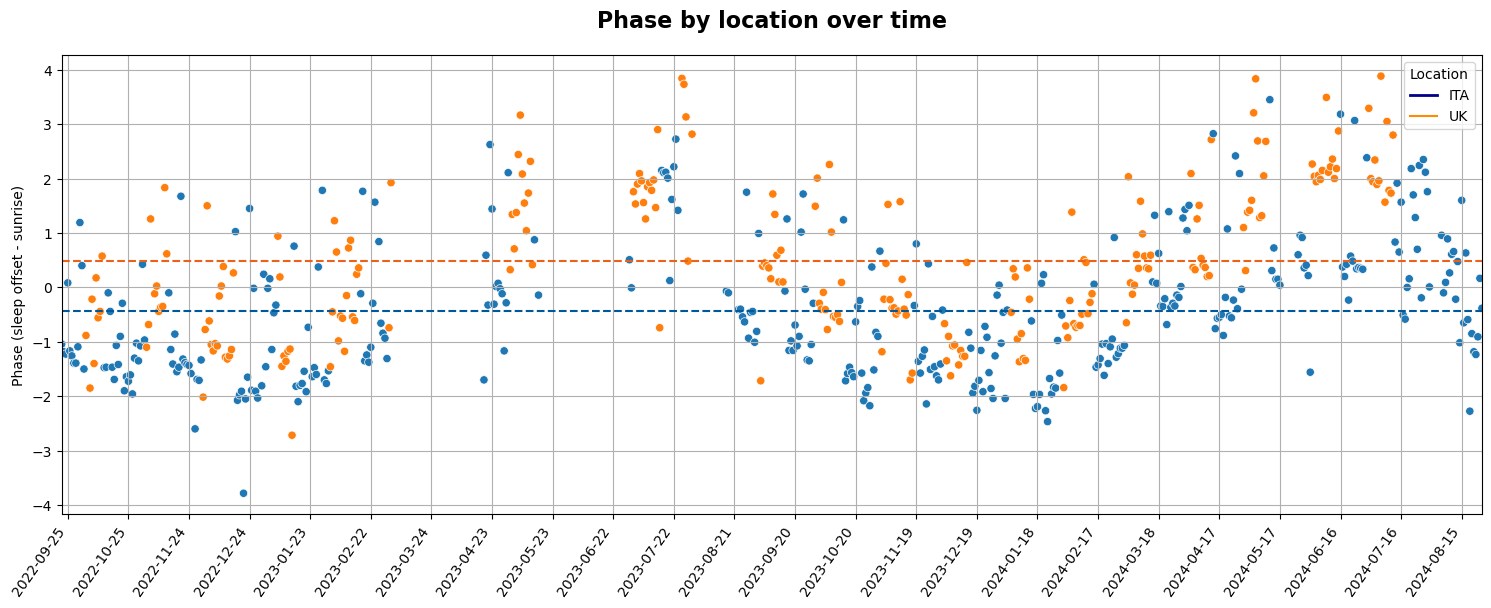

In [106]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase', hue='location', data=data_phase)
plt.title('Phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())

plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange')])
# get the current axes then set the x-axis major locator
# plot.gca()=ax if set ax = plt.gca()
plt.gca().xaxis.set_major_locator(MultipleLocator(30)) 

#add the mean of the phase for the two locations
plt.axhline(df[df['location'] == 'ITA']['phase'].mean(), color='#00589c', linestyle='--', label='ITA mean')
plt.axhline(df[df['location'] == 'UK']['phase'].mean(), color='#ec611a', linestyle='--', label='UK mean')

plt.show()